In [1]:
from fits_io import scan_dataset, update_headers, dataset_metadata, object_in_fov
from fits_io import identify_objects, cleanup_intermediate_files 
from fits_io import flag_object_in_fov, load_dataset_objects
from reduccion import run_reduction, plot_reduction
from astrometria import run_astrometry
import pandas as pd
from pathlib import Path
from utils import load_config, Tee
from datetime import datetime
import sys



# -----------------------------------------------------------------------------
# Load settings
# -----------------------------------------------------------------------------

config_file="config.yaml"
cfg = load_config(config_file)

BASE = Path(cfg["paths"]["BASE"])
data_dir = Path(BASE, cfg["paths"]["data_dir"])
object_dir = Path(BASE, cfg["paths"]["objects_dir"])
night = cfg["night"]
night_dir = Path(BASE, data_dir, night)
objects_csv = Path(BASE, "objetos.csv")

gain = cfg["instrument"]["gain"]
rdnoise = cfg["instrument"]["rdnoise"]

steps = cfg["steps"]

print(f"Running pipeline in night dir: {night_dir}")
# -------------------------------------------------------------------------
# Redirect stdout/stderr to a single log file (append)
# -------------------------------------------------------------------------
log_file = night_dir / "pipeline.log"
#sys.stdout = Tee(log_file)
#sys.stderr = sys.stdout

print("\n"*4 + "="*80)
print(f"New pipeline run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# -------------------------------------------------------------------------
# 1) Scan dataset
# -------------------------------------------------------------------------
dataset = scan_dataset(night_dir)

#objects = identify_objects(dataset["images_raw"])


# -------------------------------------------------------------------------
# 2) Update headers
# -------------------------------------------------------------------------
if steps.get("update_headers", False):
    print("→ Updating FITS headers")
    update_headers(dataset["all"], gain=gain, rdnoise=rdnoise)

# -------------------------------------------------------------------------
# 3) Export metadata
# -------------------------------------------------------------------------
if steps.get("export_metadata", False):
    output_file = cfg["metadata"].get("dataset_metadata_file", "images_data.csv")
    print(f"→ Exporting metadata to {output_file}")
    raw_metadata_file = dataset_metadata(dataset, night_dir, output_file=output_file,
                                         objects_csv="objetos.csv")
    # Load objects list
    objects = load_dataset_objects(night_dir, output_file)

    

# -------------------------------------------------------------------------
# 4) Reduction
# -------------------------------------------------------------------------
if steps.get("reduction", False):
    print("→ Running reduction")

    reduction_cfg = cfg.get("reduction", {})
    reduction_result = run_reduction(
        dataset=dataset,
        zero_correction=reduction_cfg.get("zero_correction", True),
        flat_correction=reduction_cfg.get("flat_correction", True),
        dark_correction=reduction_cfg.get("dark_correction", False),
    )
else:
    reduction_result = None
    
# -------------------------------------------------------------------------
# 4.a) Plot de reducción
# -------------------------------------------------------------------------
if cfg["qc"].get("reduction_images", False):
    print("→ Generating reduction plots")
    for objname in objects:
        print(f"   → Object: {objname}")

        plot_reduction(
            dataset=output_file,
            night_dir=night_dir,
            objname=objname,
            output_name=f"reduction_{objname}.png",
            show=False
        )
    

# -------------------------------------------------------------------------
# 5) Astrometry
# -------------------------------------------------------------------------
if steps.get("astrometry", False):
    print("→ Running astrometry")

    astro_cfg = cfg.get("astrometry", {})
    run_astrometry(
        dataset=dataset,
        output_dir=night_dir,
        api_key=astro_cfg["api_key"],
        overwrite=astro_cfg.get("overwrite", True),
    )
dataset = scan_dataset(night_dir)
metadata_file = dataset_metadata(dataset, night_dir,
                                output_file=output_file)
# -------------------------------------------------------------------------
# 5.5) Images contains its object?
# -------------------------------------------------------------------------
if steps.get("contains_obj", False):
    print("→ Flagging not contained images")
    df = flag_object_in_fov(metadata_file,
                       objects_csv,
                       night_dir,
                       overwrite=False)
metadata_file = dataset_metadata(dataset, night_dir,
                                output_file=output_file)
                       

'''
# -------------------------------------------------------------------------
# 6) Cleanup
# -------------------------------------------------------------------------
if steps.get("cleanup", False):
    print("→ Cleaning intermediate files")
    cleanup_intermediate_files(data_dir)
'''
print("✓ Pipeline finished successfully")





Running pipeline in night dir: /home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis




New pipeline run: 2026-01-16 16:45:12
→ Exporting metadata to images_data.csv
→ Generating reduction plots
   → Object: OGLE-2025-BLG-0451
   Plot already exists: /home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis/reduction_OGLE-2025-BLG-0451.png (overwrite=False). Skipping.
   → Object: OGLE-2025-BLG-0675
   Plot already exists: /home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis/reduction_OGLE-2025-BLG-0675.png (overwrite=False). Skipping.
   → Object: OGLE-2025-GD-0001
   Plot already exists: /home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis/reduction_OGLE-2025-GD-0001.png (overwrite=False). Skipping.
→ Flagging not contained images
✓ Pipeline finished successfully


In [2]:
ds = pd.read_csv(Path(night_dir, output_file))
#ds[(ds["CALIBZ"]=="None")&(ds["# IMAGETYP"]=="object")]["OBJ_MATCH_STATUS"].value_counts()
ds[ds["CONTAINS_OBJECT"]=="False"]

,# IMAGETYP,CALIBZ,CALIBF,ASTROMET,OBJECT,RA,DEC,EXPTIME,GAIN,RDNOISE,FILTERS,DATE-OBS,TIME-OBS,MJD-OBS,AIRMASS,FILENAME,OBJ_MATCH_STATUS,CONTAINS_OBJECT


In [3]:
ds[ds["CALIBZ"]=="None"]
#ds[ds["ASTROMET"]=="yes"]

,# IMAGETYP,CALIBZ,CALIBF,ASTROMET,OBJECT,RA,DEC,EXPTIME,GAIN,RDNOISE,FILTERS,DATE-OBS,TIME-OBS,MJD-OBS,AIRMASS,FILENAME,OBJ_MATCH_STATUS,CONTAINS_OBJECT
235,object,None,None,None,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,V,2025-08-24T03:27:38.016,03:27:38.349,60911.144190,1.35,OGLE-2025-BLG-0451v0001.fit,OK,None
236,object,None,None,None,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,V,2025-08-24T03:29:45.974,03:29:46.390,60911.145671,1.36,OGLE-2025-BLG-0451v0002.fit,OK,None
237,object,None,None,None,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,V,2025-08-24T03:31:54.019,03:31:54.372,60911.147153,1.37,OGLE-2025-BLG-0451v0003.fit,OK,None
238,object,None,None,None,OGLE-2025-BLG-0451,17:59:42.3,-19:58:26.9,120.0,2.0,15.7,V,2025-08-24T03:34:01.978,03:34:02.419,60911.148634,1.38,OGLE-2025-BLG-0451v0004.fit,OK,None
239,object,None,None,None,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,V,2025-08-24T03:36:08.986,03:36:10.401,60911.150104,1.39,OGLE-2025-BLG-0451v0005.fit,OK,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,flat,None,None,None,skyflat,16:55:37.5,-31:47:15.1,2.4,2.0,15.7,V,2025-08-22T22:29:25.958,22:29:27.318,60909.937106,1.02,flatv0012.fit,NOT_CHECKED,None
387,flat,None,None,None,skyflat,16:55:37.2,-31:47:15.1,2.4,2.0,15.7,V,2025-08-22T22:29:35.981,22:29:37.428,60909.937222,1.02,flatv0013.fit,NOT_CHECKED,None
388,flat,None,None,None,skyflat,16:55:37.1,-31:47:15.1,2.4,2.0,15.7,V,2025-08-22T22:29:46.003,22:29:47.479,60909.937338,1.02,flatv0014.fit,NOT_CHECKED,None
389,flat,None,None,None,skyflat,16:55:37.4,-31:47:15.1,2.4,2.0,15.7,V,2025-08-22T22:29:56.976,22:29:57.589,60909.937465,1.02,flatv0015.fit,NOT_CHECKED,None


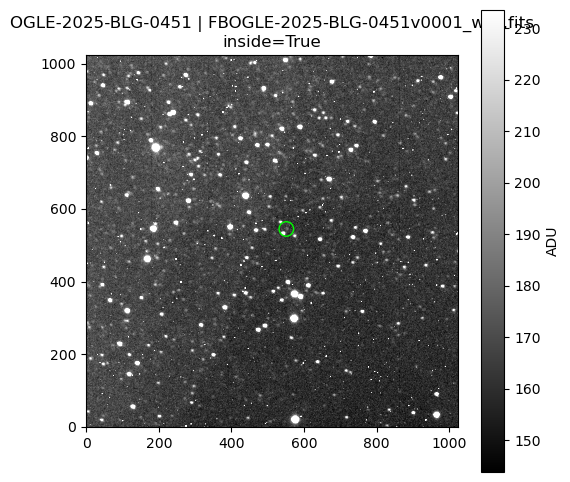

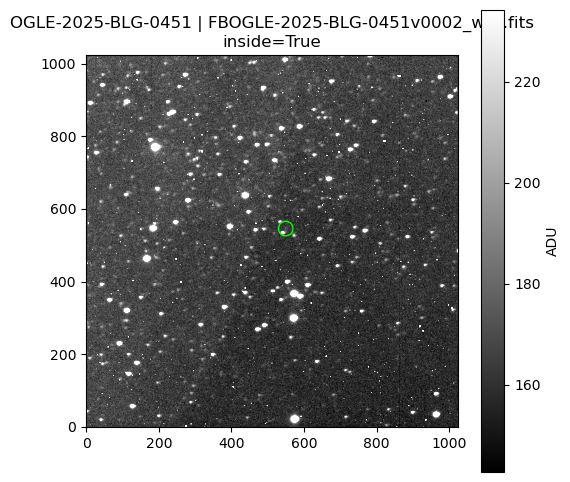

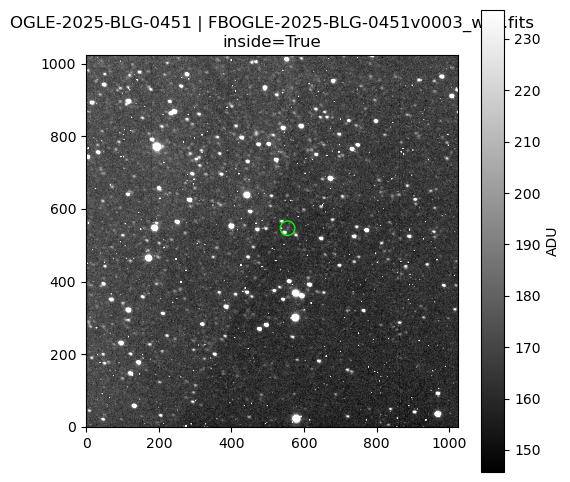

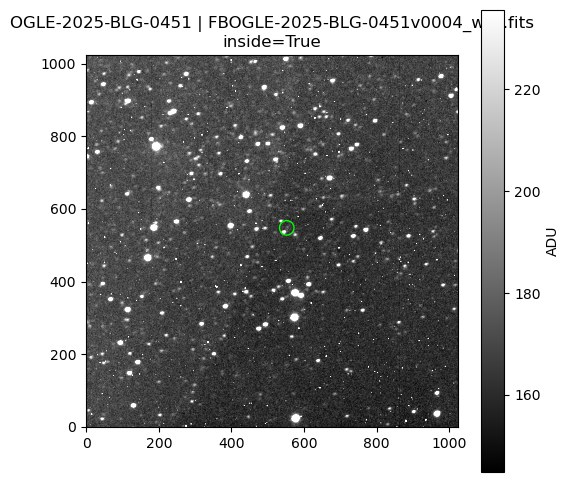

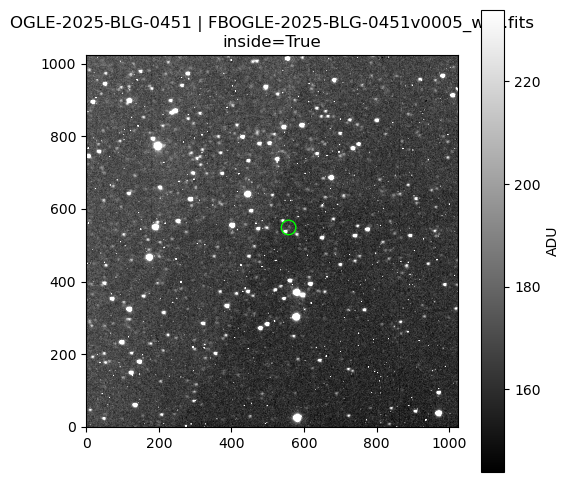

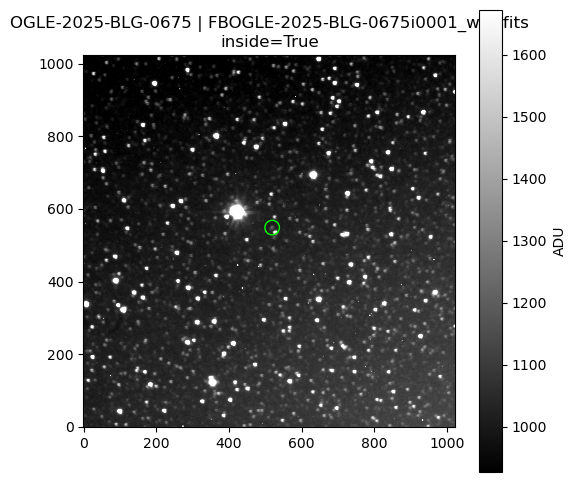

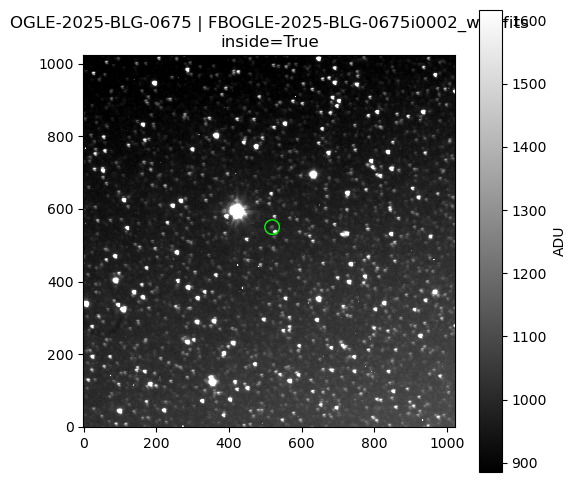

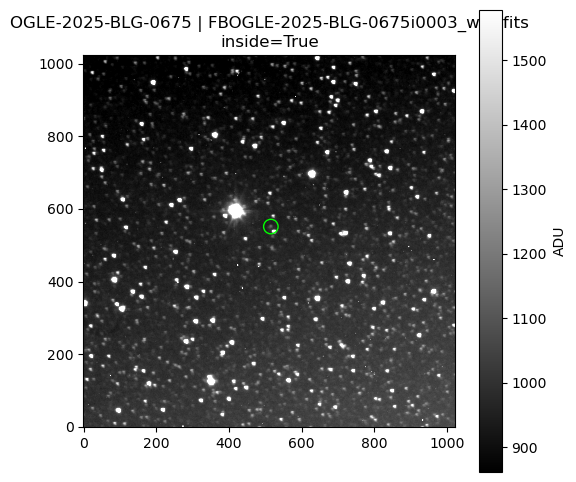

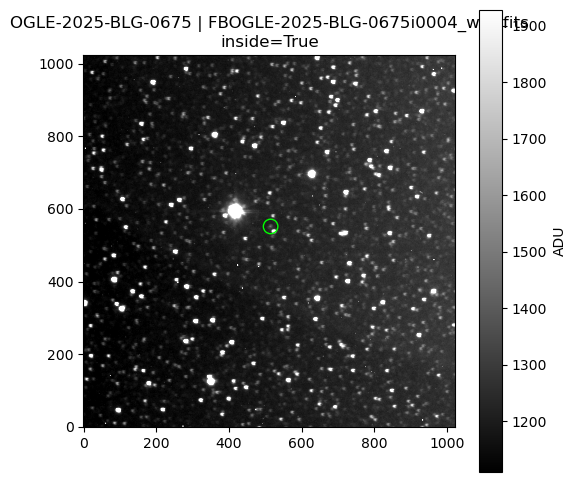

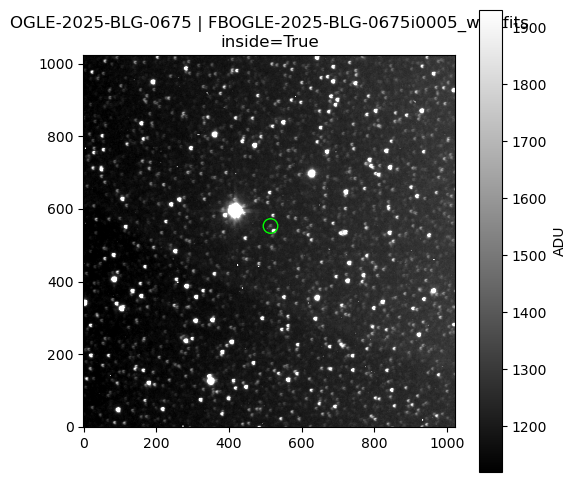

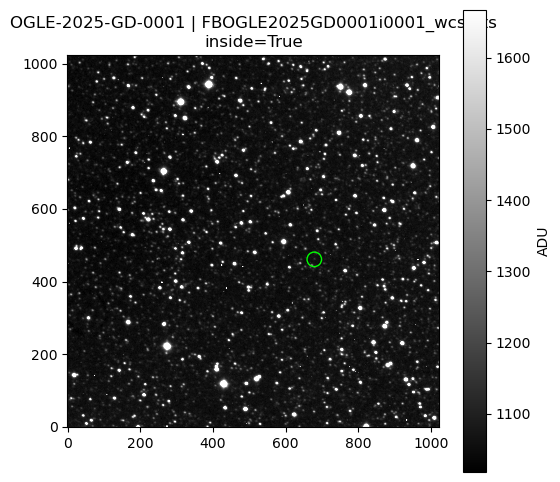

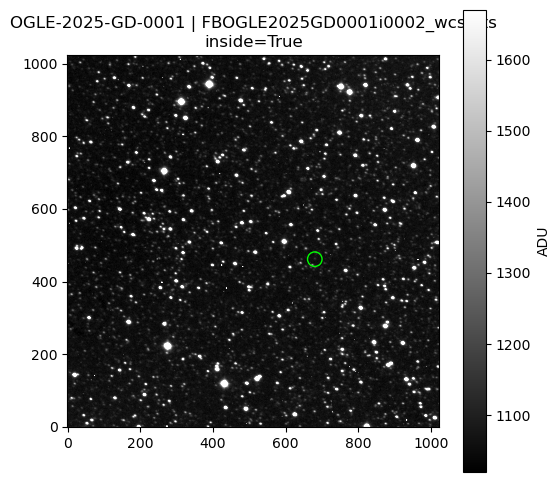

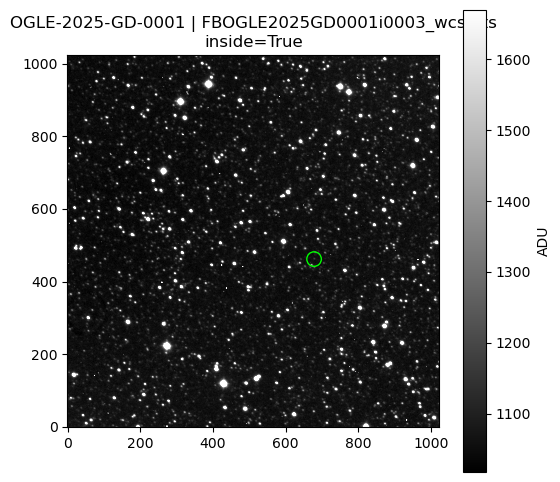

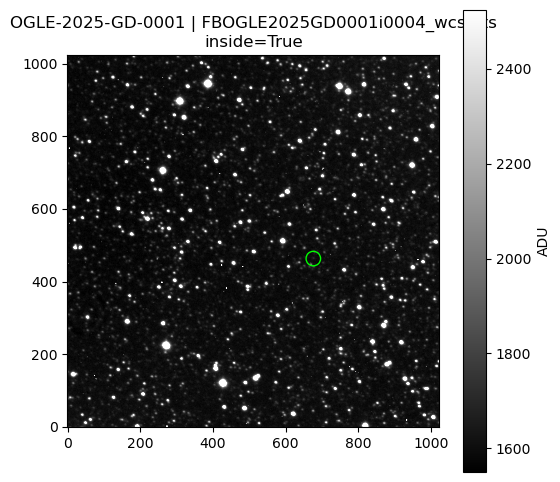

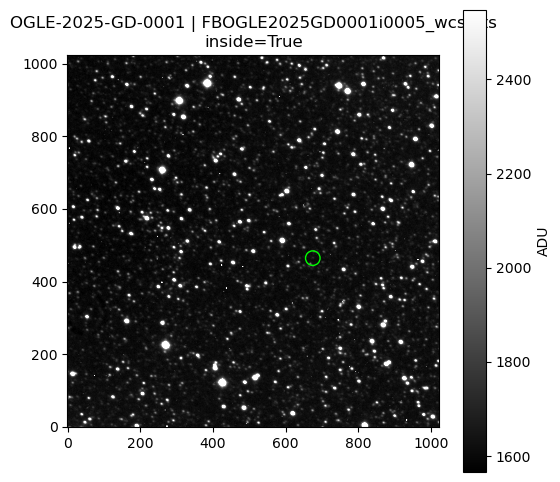

In [20]:
%matplotlib inline

from collections import defaultdict
from matplotlib.patches import Circle


images = dataset["images_astro"]

outdir = Path(night_dir, "astrometry_debug")
outdir.mkdir(exist_ok=True)

max_per_object = 5
counter = defaultdict(int)

for f in images:

    with fits.open(f) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        wcs = WCS(header)

    obj_name = header.get("OBJECT", "").strip()

    # si no hay nombre de objeto, salteo
    if not obj_name:
        continue

    # si ya ploteé suficientes de este objeto, salteo
    if counter[obj_name] >= max_per_object:
        continue

    match = objects_df[objects_df["objeto"] == obj_name]
    if match.empty:
        continue

    ra_obj = match.iloc[0]["ra_deg"]
    dec_obj = match.iloc[0]["dec_deg"]
    obj_coord = SkyCoord(ra_obj * u.deg, dec_obj * u.deg)

    x, y = wcs.world_to_pixel(obj_coord)
    ny, nx = data.shape
    inside = (0 <= x < nx) and (0 <= y < ny)

    vmin, vmax = np.percentile(data, (5, 99))


    radius_pix = 20  # radio del círculo en píxeles

    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(
        data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    circle = Circle(
        (x, y),
        radius=radius_pix,
        edgecolor="lime" if inside else "red",
        facecolor="none",
        linewidth=1
    )
    ax.add_patch(circle)

    ax.set_title(f"{obj_name} | {f.name}\ninside={inside}")

    plt.colorbar(im, ax=ax, label="ADU")
    plt.show()


    counter[obj_name] += 1


In [29]:
ds["OBJ_MATCH_STATUS"].value_counts()

NOT_CHECKED    493
Name: OBJ_MATCH_STATUS, dtype: int64

In [ ]:
ds = pd.read_csv(str(Path(night_dir, output_file)))
ds_obj = ds[(ds["OBJECT"] == objname) and (ds["ASTROMET"]=="None")]
raw_files = [
    Path(night_dir, fname)
    for fname in ds_obj[ds_obj["CALIBZ"] == "None"]["FILENAME"]
]
bias_files = [
    Path(night_dir, fname)
    for fname in ds_obj[(ds_obj["CALIBZ"] == "subtracted bias")
                        & (ds_obj["CALIBF"] == "None")]["FILENAME"]
]
flatbias_files = [
    Path(night_dir, fname)
    for fname in ds_obj[ds_obj["CALIBF"] == "flat correction"]["FILENAME"]
]
print(len(raw_files))
print(len(bias_files))
print(len(flatbias_files))

68
68
136


NameError: name 'hdr' is not defined

In [26]:
ds_obj[(ds_obj["CALIBZ"] == "subtracted bias")& (ds_obj["CALIBF"] == "None")]

,# IMAGETYP,CALIBZ,CALIBF,OBJECT,RA,DEC,EXPTIME,GAIN,RDNOISE,FILTERS,DATE-OBS,TIME-OBS,MJD-OBS,AIRMASS,FILENAME,OBJ_MATCH_STATUS
32,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:22.3,-55:51:29.0,120.0,2.0,15.7,I,2025-08-24T00:19:23.030,00:19:24.305,60911.013461,1.15,BOGLE2025GD0001i0001.fit,NOT_CHECKED
33,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:22.3,-55:51:29.0,120.0,2.0,15.7,I,2025-08-24T00:21:30.989,00:21:32.351,60911.014942,1.15,BOGLE2025GD0001i0002.fit,NOT_CHECKED
34,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:22.0,-55:51:29.0,120.0,2.0,15.7,I,2025-08-24T00:23:39.034,00:23:40.394,60911.016424,1.16,BOGLE2025GD0001i0003.fit,NOT_CHECKED
35,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:22.1,-55:51:29.0,180.0,2.0,15.7,I,2025-08-24T00:26:16.973,00:26:18.206,60911.018252,1.16,BOGLE2025GD0001i0004.fit,NOT_CHECKED
36,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:21.9,-55:51:29.0,180.0,2.0,15.7,I,2025-08-24T00:29:24.979,00:29:26.210,60911.020428,1.16,BOGLE2025GD0001i0005.fit,NOT_CHECKED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:18.3,-55:51:29.0,120.0,2.0,15.7,V,2025-08-24T02:53:12.019,02:53:12.455,60911.120278,1.54,BOGLE2025GD0001v0014.fit,NOT_CHECKED
96,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:18.2,-55:51:29.0,120.0,2.0,15.7,V,2025-08-24T02:55:19.027,02:55:20.501,60911.121748,1.55,BOGLE2025GD0001v0015.fit,NOT_CHECKED
97,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:18.1,-55:51:29.0,120.0,2.0,15.7,V,2025-08-24T02:57:28.022,02:57:28.482,60911.123241,1.56,BOGLE2025GD0001v0016.fit,NOT_CHECKED
98,object,subtracted bias,None,OGLE-2025-GD-0001,16:12:18.0,-55:51:29.0,120.0,2.0,15.7,V,2025-08-24T02:59:35.981,02:59:36.523,60911.124722,1.57,BOGLE2025GD0001v0017.fit,NOT_CHECKED


In [ ]:
print(f"{'Clave':<20} | {'Cantidad':>8} | {'Tipo':<15}")
print("-" * 60)

for key, value in objects.items():
    if hasattr(value, "__len__"):
        tipo = type(value).__name__
        cantidad = len(value)
        if tipo == "list" and len(value) != 0:
            tipo = f"{tipo} ({type(value[0]).__name__})"
    else:
        tipo = type(value).__name__
        cantidad = "N/A"

    print(f"{str(key):<20} | {cantidad:>8} | {tipo:<15} ")

print("=" * 60)

Clave                | Cantidad | Tipo           
------------------------------------------------------------
OGLE-2025-BLG-0451   |       12 | list (PosixPath) 
OGLE-2025-BLG-0675   |       20 | list (PosixPath) 
OGLE-2025-GD-0001    |       68 | list (PosixPath) 


In [17]:
print(f"{'Clave':<20} | {'Cantidad':>8} | {'Tipo':<15}")
print("-" * 60)

for key, value in dataset.items():
    if hasattr(value, "__len__"):
        tipo = type(value).__name__
        cantidad = len(value)
        if tipo == "list" and len(value) != 0:
            tipo = f"{tipo} ({type(value[0]).__name__})"
    else:
        tipo = type(value).__name__
        cantidad = "N/A"

    print(f"{str(key):<20} | {cantidad:>8} | {tipo:<15} ")

print("=" * 60)


Clave                | Cantidad | Tipo           
------------------------------------------------------------
dir                  |      N/A | PosixPath       
all                  |      493 | list (PosixPath) 
bias                 |       20 | list (PosixPath) 
darks_raw            |        0 | list            
darks_cal            |        0 | list            
flats_raw            |       35 | list (PosixPath) 
flats_cal            |       35 | list (PosixPath) 
images_raw           |      100 | list (PosixPath) 
images_cal           |      100 | list (PosixPath) 
images_flat          |      100 | list (PosixPath) 
images_astro         |      100 | list (PosixPath) 


In [10]:
from astropy.io.fits import getheader, getval
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
max_sep_deg = 0.5
output_path = Path(night_dir, output_file)
keys = [
    'IMAGETYP', 'CALIBZ', 'CALIBF', 'OBJECT', 'RA', 'DEC', 'EXPTIME', 'GAIN',
    'RDNOISE', 'FILTERS', 'DATE-OBS', 'TIME-OBS', 'MJD-OBS', 'AIRMASS',
    'FILENAME', 'OBJ_MATCH_STATUS'
]
objects_csv = "objetos.csv"
objects_df = pd.read_csv(objects_csv)
if objects_csv is not None:
    catalog_coords = SkyCoord(
        ra=objects_df["ra_deg"].values * u.deg,
        dec=objects_df["dec_deg"].values * u.deg
    )
values = []
for file in dataset["images_astro"]:
    hdr = getheader(file)
    if file in dataset["images_astro"]:
        ra = hdr.get("RA")
        dec = hdr.get("DEC")
        img_coord = SkyCoord(ra=ra, dec=dec, unit=(u.hourangle, u.deg))
        sep = img_coord.separation(catalog_coords)
        min_sep = sep.min()
        best_idx = sep.argmin()

        if min_sep < max_sep_deg * u.deg:
            true_name = objects_df.iloc[best_idx]["objeto"]
            if hdr["OBJECT"]!=true_name:
                hdr["ORIG_OBJ"] = hdr["OBJECT"]
                hdr["OBJECT"] = true_name
        

    

#    values.append([header.get(key) for key in keys])

#header_str = ",".join(keys)
#np.savetxt(output_path, values, fmt="%s", delimiter=",", header=header_str)

In [39]:
true_name

'OGLE-2025-BLG-0397'

In [20]:
min_sep, max_sep_deg*u.deg

(<Angle 0.3629144 deg>, <Quantity 0.15 deg>)

In [11]:
hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
ADCRATE = '          '           / analog to digital converter rate             
GAIN    =                  2.0 / CCD gain (e-/ADU)                              
RDNOISE =                 15.7 / Readout noise (e- RMS)                         
CAMTEM  =                -44